# Dependencies
#### Run the following file(s) before running this code.
- 03_baseline_similarity_graph.ipynb (or 03b)

##### Note:
URL of the Neo4j browser:
- https://[IP address]:7473/browser/

ID & Pass: 
- Use the one in .env


In [1]:
# Config
DB_NAME:str         = "project03"
COLLECTION_NAME:str = "complaints"

In [2]:
import time
from datetime import datetime, timedelta

In [3]:
import pandas as pd
import numpy as np
import sys
import os
# from openai import OpenAI
import time
from pymongo import MongoClient
from dotenv import load_dotenv
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

In [4]:
import neo4j
import pandas as pd
from IPython.display import display

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import plotly.express as px

In [7]:
from dotenv import load_dotenv  
load_dotenv()

True

In [8]:
# Timestamp (Start)
current_datetime = datetime.now()
formatted_time = current_datetime.strftime("%Y-%m-%d_%H:%M:%S")
print(formatted_time)

start_time = time.time()

2026-01-08_21:56:11


### MongoDB
#### Load data from the existing database

In [9]:
# Connect to the mongo database
# mongodb is the protocol; mongo is the hostname, which for us is the container name; 27017 is the TCP port number
mongo = MongoClient("mongodb://mongo:27017/")

In [10]:
# Access to the existing mongo database (this seems to be the same command with creating a new database)
db = mongo[DB_NAME]

In [11]:
# Connect to the existing collection (this seems to be the same command with creating a new collection)
collection = db[COLLECTION_NAME]

In [12]:
# # An example of the data in mongo
# collection.find_one()

In [13]:
cursor = collection.find({}, {"_id": 0})
df = pd.DataFrame(cursor)

In [14]:
df.head()

,date_received,product,sub_product,issue,sub_issue,consumer_complaint_narrative,company_public_response,company,state,zip_code,date_sent_to_company,company_response_to_consumer,complaint_id,embeddings,similar_items
0,06/02/25,Vehicle loan or lease,Loan,Managing the loan or lease,Problem with the interest rate,Issue : I have been making consistent payments...,Unknown,Lendmark Financial Services,VA,20171,06/02/25,Closed with explanation,13856239,"[-0.009881553240120413, -0.0016333360690623522...","[{'complaint_id': 13918605, 'similarity_score'..."
1,06/01/25,Debt collection,Medical debt,Attempts to collect debt not owed,Debt was paid,The bill was supposed to be taken cared of and...,Company has responded to the consumer and the ...,"P.S.C., Inc",WA,98503,06/01/25,Closed with explanation,13830009,"[0.04577404260635376, -0.01870175078511238, -0...","[{'complaint_id': 13938840, 'similarity_score'..."
2,06/05/25,Prepaid card,Government benefit card,Problem with a purchase or transfer,Card company isn't resolving a dispute about a...,My card they took out my account times and wan...,Unknown,Comerica,AL,365XX,06/05/25,Closed with monetary relief,13925667,"[0.01438137236982584, -0.01985330879688263, 0....","[{'complaint_id': 13922553, 'similarity_score'..."
3,06/03/25,"Money transfer, virtual currency, or money ser...",Virtual currency,Fraud or scam,Unknown,I tried to log in to my Coinbase account. I go...,Unknown,"Coinbase, Inc.",FL,32533,06/03/25,Closed with monetary relief,13866764,"[0.014162255451083183, -0.02944198250770569, -...","[{'complaint_id': 13931368, 'similarity_score'..."
4,06/08/25,"Money transfer, virtual currency, or money ser...",Mobile or digital wallet,Unauthorized transactions or other transaction...,Unknown,On //year> there was a transaction from to my ...,Unknown,Chime Financial Inc,PA,15301,06/08/25,Closed with explanation,13958210,"[-0.00914121326059103, -0.02843334898352623, -...","[{'complaint_id': 13960484, 'similarity_score'..."


### Neo4j

In [15]:
driver = neo4j.GraphDatabase.driver(uri="neo4j://neo4j:7687", auth=("neo4j","ucb_mids_w205"))

In [16]:
session = driver.session(database="neo4j")

# Business Case

Companies receive thousands of consumer complaints daily. Manually identifying patterns is impossible at scale, so we need automated methods to detect clusters of similar complaints.  

By embedding complaint narratives, building a similarity graph, and running gds algorithms, we can:

- Detect communities of complaints (ex. same product issue or recurring service problem)
- Identify the most central complaints using PageRank, Betweenness, and Degree
- Prioritize operational fixes, improve customer satisfaction, and reduce response times
  
In the end, I ran Louvain to detect communities, PageRank to identify influential complaints, WCC to see connectivity, and Betweenness to measure bridging complaints.


In [17]:
def my_neo4j_run_query_pandas(query, **kwargs):
    "run a query and return the results in a pandas dataframe"
    
    result = session.run(query, **kwargs)
    
    df = pd.DataFrame([r.values() for r in result], columns=result.keys())
    
    return df

In [18]:
def my_neo4j_nodes_relationships():
    "print all the nodes and relationships"
   
    print("-------------------------")
    print("  Nodes:")
    print("-------------------------")
    
    query = """
        match (n) 
        return n.complaint_id as node_name, n.consumer_complaint_narrative as label
        order by n.complaint_id
    """
    
    df = my_neo4j_run_query_pandas(query)
    
    number_nodes = df.shape[0]
    
    display(df)
    
    print("-------------------------")
    print("  Relationships:")
    print("-------------------------")
    
    query = """
        match (n1:Complaint)-[r:SIMILAR]->(n2:Complaint)
        return n1.complaint_id AS node_name_1,
               labels(n1) AS node_1_labels,
               type(r) AS relationship_type,
               n2.complaint_id AS node_name_2,
               labels(n2) AS node_2_labels,
               r.score AS weight
        order by node_name_1, node_name_2
    """
    
    df = my_neo4j_run_query_pandas(query)
    
    number_relationships = df.shape[0]
    
    display(df)
    
    density = (2 * number_relationships) / (number_nodes * (number_nodes - 1))
    
    print("-------------------------")
    print("  Density:", f"{density:.1f}")
    print("-------------------------")
    

In [19]:
my_neo4j_nodes_relationships()

-------------------------
  Nodes:
-------------------------


,node_name,label
0,13820989,"To Whom It May Concern, I am writing to formal..."
1,13822484,Subject : Unauthorized Solar Loan Agreement Di...
2,13822776,My phone has been hacked through . Theyre stil...
3,13822789,My personal and financial data was compromised...
4,13826021,I have reason to believe Chase is violating th...
...,...,...
245,13961980,"I am a victim of identity theft, and I am requ..."
246,13962010,Final Dispute Letter to Innovis Assistance Dat...
247,13962255,"I am a victim of identity theft, and I am requ..."
248,13962646,"TO : Fair Collections & Outsourcing , Inc . At..."


Received notification from DBMS server: <GqlStatusObject gql_status='01N42', status_description="One of the property names in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your application (the missing property name is: score)", position=<SummaryInputPosition line=8, column=18, offset=302>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/', '_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'column': 18, 'offset': 302, 'line': 8}}> for query: '\n        match (n1:Complaint)-[r:SIMILAR]->(n2:Complaint)\n        return n1.complaint_id AS node_name_1,\n               labels(n1) AS node_1_labels,\n               type(r) AS relationship_type,\n               n2.com

-------------------------
  Relationships:
-------------------------


,node_name_1,node_1_labels,relationship_type,node_name_2,node_2_labels,weight
0,13820989,[Complaint],SIMILAR,13832603,[Complaint],None
1,13820989,[Complaint],SIMILAR,13846113,[Complaint],None
2,13820989,[Complaint],SIMILAR,13912263,[Complaint],None
3,13820989,[Complaint],SIMILAR,13931291,[Complaint],None
4,13820989,[Complaint],SIMILAR,13949647,[Complaint],None
...,...,...,...,...,...,...
1041,13962646,[Complaint],SIMILAR,13912263,[Complaint],None
1042,13963767,[Complaint],SIMILAR,13832603,[Complaint],None
1043,13963767,[Complaint],SIMILAR,13849796,[Complaint],None
1044,13963767,[Complaint],SIMILAR,13944820,[Complaint],None


-------------------------
  Density: 0.0
-------------------------


In [20]:
my_neo4j_run_query_pandas(""" MATCH ()-[r:SIMILAR]->() RETURN COUNT(r) AS num_edges """)


,num_edges
0,1046


In [21]:
def drop_graph():
    try:
        my_neo4j_run_query_pandas("CALL gds.graph.drop('graph', false) yield graphName")
    except:
        pass


In [22]:
def create_similarity_graph():
    query = """
    CALL gds.graph.project(
        "graph",
        "Complaint",
        {
            SIMILAR: {
                type: "SIMILAR",
                properties: 'similarity_score',
                orientation: "NATURAL"
            }
        }
    )
    """
    return my_neo4j_run_query_pandas(query)


## Graph Algorithms Applied
- Louvain: Generates `community` for each complaint
- PageRank: Adds `pagerank` score to each complaint node
- Betweenness: Adds `betweenness` score
- WCC: Adds `wcc` identifier

In [23]:
def gds_wcc():
    query = """
    CALL gds.wcc.stream("graph")
    YIELD nodeId, componentId
    RETURN gds.util.asNode(nodeId).complaint_id AS complaint_id, componentId
    ORDER BY componentId
    """
    return my_neo4j_run_query_pandas(query)


In [24]:
def gds_pagerank():
    query = """
    CALL gds.pageRank.stream("graph")
    YIELD nodeId, score
    RETURN gds.util.asNode(nodeId).complaint_id AS complaint_id, score
    ORDER BY score DESC
    """
    return my_neo4j_run_query_pandas(query)


In [25]:
def gds_betweenness():
    query = """
    CALL gds.betweenness.stream("graph")
    YIELD nodeId, score
    RETURN gds.util.asNode(nodeId).complaint_id AS complaint_id, score
    ORDER BY score DESC
    """
    return my_neo4j_run_query_pandas(query)


In [26]:
def gds_betweenness_weight():
    query = """
    CALL gds.betweenness.stream("graph", { relationshipWeightProperty: 'similarity_score' })
    YIELD nodeId, score
    RETURN gds.util.asNode(nodeId).complaint_id AS complaint_id, score
    ORDER BY score DESC
    """
    return my_neo4j_run_query_pandas(query)


In [27]:
def gds_degree():
    query = """
    CALL gds.degree.stream("graph")
    YIELD nodeId, score
    RETURN gds.util.asNode(nodeId).complaint_id AS complaint_id, score
    ORDER BY score DESC
    """
    return my_neo4j_run_query_pandas(query)


In [28]:
def gds_louvain():
    query = """
    CALL gds.louvain.stream("graph")
    YIELD nodeId, communityId
    RETURN gds.util.asNode(nodeId).complaint_id AS complaint_id, 
           communityId AS community_id
    """
    return my_neo4j_run_query_pandas(query)

In [29]:
drop_graph()
create_similarity_graph()

wcc_df = gds_wcc()
pg_df = gds_pagerank()
btw_df = gds_betweenness()
btw_wei_df = gds_betweenness_weight()
deg_df = gds_degree()
louvain_df = gds_louvain()

In [30]:
wcc_df

,complaint_id,componentId
0,13932152,0
1,13873072,0
2,13834309,0
3,13939523,0
4,13883114,0
...,...,...
245,13931368,0
246,13862723,0
247,13937972,0
248,13956026,0


In [31]:
pg_df

,complaint_id,score
0,13894035,13.293873
1,13949647,10.636082
2,13912263,7.188099
3,13842806,6.376085
4,13832603,5.310437
...,...,...
245,13913533,0.150000
246,13959361,0.150000
247,13893892,0.150000
248,13911705,0.150000


In [32]:
louvain_df

,complaint_id,community_id
0,13932152,24
1,13873072,248
2,13834309,248
3,13939523,24
4,13883114,24
...,...,...
245,13931368,248
246,13862723,24
247,13937972,248
248,13956026,248


In [33]:
btw_df

,complaint_id,score
0,13930008,3211.321588
1,13848670,2818.379468
2,13939090,2470.225256
3,13945479,2309.913827
4,13923898,2308.568609
...,...,...
245,13959361,0.000000
246,13893892,0.000000
247,13911705,0.000000
248,13950273,0.000000


In [34]:
btw_wei_df

,complaint_id,score
0,13930008,3076.0
1,13848670,2591.0
2,13939090,2550.0
3,13923898,2355.0
4,13922553,2299.0
...,...,...
245,13959361,0.0
246,13893892,0.0
247,13911705,0.0
248,13950273,0.0


In [35]:
deg_df

,complaint_id,score
0,13834309,5.0
1,13883114,5.0
2,13926731,5.0
3,13820989,5.0
4,13931188,5.0
...,...,...
245,13912495,1.0
246,13826440,1.0
247,13937972,1.0
248,13894035,0.0


In [36]:
# Write PageRank back to the knowledge graph
# Property: pagerank
for _, row in pg_df.iterrows():
    session.run("""
    MATCH (c:Complaint {complaint_id: $complaint_id})
    SET c.pagerank = $score
    """, {"complaint_id": row["complaint_id"], "score": float(row["score"])})

In [37]:
# Write betweenness back to the knowledge graph
# Property: betweenness
for _, row in btw_df.iterrows():
    session.run("""
    MATCH (c:Complaint {complaint_id: $complaint_id})
    SET c.betweenness = $score
    """, {"complaint_id": row["complaint_id"], "score": float(row["score"])})

In [38]:
# Write betweenness (weighted) back to the knowledge graph
# Property: betweenness
for _, row in btw_wei_df.iterrows():
    session.run("""
    MATCH (c:Complaint {complaint_id: $complaint_id})
    SET c.weighted_betweenness = $score
    """, {"complaint_id": row["complaint_id"], "score": float(row["score"])})

In [39]:
# Wrtie degree back to the knowledge graph
# Property: degree
for _, row in deg_df.iterrows():
    session.run("""
    MATCH (c:Complaint {complaint_id: $complaint_id})
    SET c.degree = $score
    """, {"complaint_id": row["complaint_id"], "score": float(row["score"])})

In [40]:
# Write weakly connected back to the knowledge graph
# Property: component
for _, row in wcc_df.iterrows():
    session.run("""
    MATCH (c:Complaint {complaint_id: $complaint_id})
    SET c.component = $component
    """, {"complaint_id": row["complaint_id"], "component": int(row["componentId"])})


In [41]:
# Write Louvain back to the knowledge graph
# Property: community_id
for _, row in louvain_df.iterrows():
    session.run("""
    MATCH (c:Complaint {complaint_id: $complaint_id})
    SET c.community_id = $community_id
    """, {"complaint_id": row["complaint_id"], "community_id": int(row["community_id"])})

## Combine all metrics into big_df for analysis
Columns:
- complaint_id
- community_id
- pagerank
- betweenness
- weighted_betweenness
- wcc

In [42]:
# Rename columns in other dfs
pg_df = pg_df.rename(columns={"score": "pagerank"})
btw_df = btw_df.rename(columns={"score": "betweenness"})
btw_wei_df = btw_wei_df.rename(columns={"score": "weighted_betweenness"})
wcc_df = wcc_df.rename(columns={"componentId": "wcc"})
deg_df = deg_df.rename(columns={"score": "degree"})
louvain_df = louvain_df.rename(columns={"community_id": "community"})

# Merge into big df
big_df = louvain_df[["complaint_id", "community"]].copy()

big_df = big_df.merge(pg_df[["complaint_id", "pagerank"]], on="complaint_id", how="left")
big_df = big_df.merge(btw_df[["complaint_id", "betweenness"]], on="complaint_id", how="left")
big_df = big_df.merge(btw_wei_df[["complaint_id", "weighted_betweenness"]], on="complaint_id", how="left")
big_df = big_df.merge(wcc_df[["complaint_id", "wcc"]], on="complaint_id", how="left")
big_df = big_df.merge(deg_df[["complaint_id", "degree"]], on="complaint_id", how="left")

big_df.head(5)


,complaint_id,community,pagerank,betweenness,weighted_betweenness,wcc,degree
0,13932152,24,2.028890,304.673275,275.0,0,3.0
1,13873072,248,1.013838,1832.660173,1937.0,0,3.0
2,13834309,248,0.201000,77.921429,97.0,0,5.0
3,13939523,24,0.325335,345.027972,270.0,0,3.0
4,13883114,24,0.179835,21.666667,20.0,0,5.0


## Business Insights
Below are the complaints that “influence” the network most.

These should be highlighted for root-cause analysis or prioritized in customer support.

In [43]:
# Top complaints per community by PageRank
top_pagerank = big_df.groupby("community").apply(
    lambda x: x.nlargest(3, "pagerank"),
    include_groups=False
).reset_index(drop=True)

# Top complaints per community by Betweenness
top_betweenness = big_df.groupby("community").apply(
    lambda x: x.nlargest(3, "betweenness"),
    include_groups=False
).reset_index(drop=True)

print(top_pagerank)
print(top_betweenness)

    complaint_id   pagerank  betweenness  weighted_betweenness  wcc  degree
0       13820989   2.944257   429.191171                 364.0    0     5.0
1       13944820   2.803554   249.720910                 308.0    0     2.0
2       13932152   2.028890   304.673275                 275.0    0     3.0
3       13894035  13.293873     0.000000                   0.0    0     0.0
4       13949647  10.636082   144.544989                 117.0    0     2.0
5       13912263   7.188099    17.928788                  16.0    0     2.0
6       13870780   1.530145  1088.593579                1089.0    0     3.0
7       13900790   1.218707   567.434596                 626.0    0     2.0
8       13950395   0.950908   210.255469                  75.0    0     2.0
9       13909819   1.781514   508.327659                 476.0    0     2.0
10      13897143   1.780697  1365.016885                1202.0    0     3.0
11      13855963   1.624578   980.920069                 929.0    0     4.0
    complain

## Some more business visualizations.

<Axes: title={'center': 'Community Sizes'}, xlabel='community'>

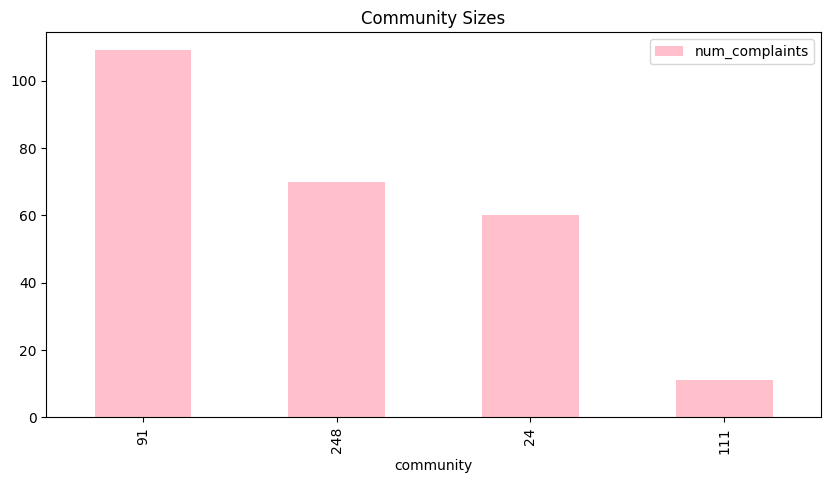

In [44]:
community_sizes = big_df["community"].value_counts().reset_index()
community_sizes.columns = ["community", "num_complaints"]
community_sizes.plot.bar(x="community", y="num_complaints", figsize=(10,5), color="pink", title="Community Sizes")

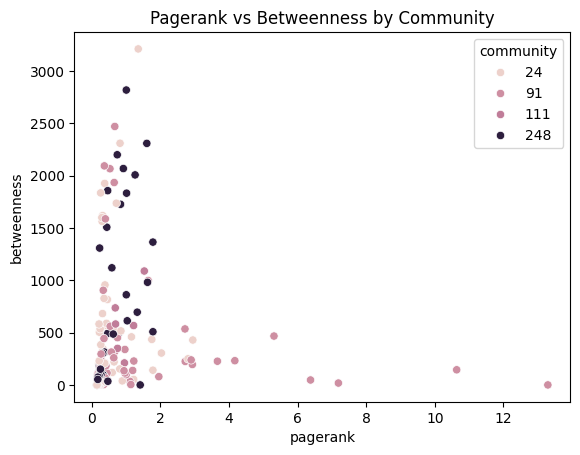

In [45]:
sns.scatterplot(
    data=big_df,
    x="pagerank",
    y="betweenness",
    hue="community"
)
plt.title("Pagerank vs Betweenness by Community")
plt.show()

In [46]:
X = np.vstack(df["embeddings"].to_numpy())

In [47]:
# reduce to 2 dims
pca = PCA(n_components=2, random_state=1234)
reduced = pca.fit_transform(X)

df["x"] = reduced[:, 0]
df["y"] = reduced[:, 1]


In [48]:
df["short_complaint"] = df["consumer_complaint_narrative"].str.slice(0, 150) + "..." #for hover info

In [49]:
fig = px.scatter(
    df,
    x="x",
    y="y",
    color="product",
    hover_data={
        "product": True,
        "short_complaint": True
    },
    title="Semantic Similarity Map of Consumer Complaints"
)

fig.update_traces()
fig.show()

## Complaint Top Similarity

The below can be used when bsuinesses need to see how top other complaints were handled.

In [50]:
query_idx = np.random.randint(0, len(df))
query_vector = np.array(df["embeddings"].iloc[query_idx]).reshape(1, -1)

similarities = cosine_similarity(query_vector, X).flatten()

top_indices = similarities.argsort()[::-1][1:6] # top 5

print("Finding complaints similar to: ")
print(f"Product: {df['product'].iloc[query_idx]}")
print(f"Complaint:\n{df['consumer_complaint_narrative'].iloc[query_idx][:400]}..")


print("\nTop 5 Similar Complaints:")
for i in top_indices:
    print()
    print(f"Similarity: {similarities[i]:.3f}")
    print(f"Product: {df['product'].iloc[i]}")
    print(f"Complaint:\n{df['consumer_complaint_narrative'].iloc[i][:400]}...")


Finding complaints similar to: 
Product: Debt collection
Complaint:
I am filing this complaint to report potentially deceptive and intimidating debt collection practices by a company that initially identified itself only as Debt Settlement, later linked to Structured Settlement at , , Nevada. Upon further investigation, I discovered this operation appears to be connected to Nationwide Capital Services , LLC. On //year>, at approximately I received a call from a re..

Top 5 Similar Complaints:

Similarity: 0.739
Product: Debt collection
Complaint:
This is my third complaint against NCS regarding a disputed auto-related debt. Each time l 've reached out to the CFPB, NCS has responded with evasive, misleading, and coercive tactics instead of transparency. They have shown a pattern of deception and manipulation, particularly regarding the presentation and handling of a promissory note they claim I knowingly agreed to. What actually happened is...

Similarity: 0.705
Product: Debt collection

In [51]:
# Timestamp (End)
current_datetime = datetime.now()
formatted_time = current_datetime.strftime("%Y-%m-%d_%H:%M:%S")
print(formatted_time)

end_time = time.time()
elapsed_seconds = end_time - start_time

# Convert elapsed seconds to minutes and seconds
minutes = int(elapsed_seconds // 60)
seconds = elapsed_seconds % 60

print(f"Program elapsed time: {minutes} minutes and {seconds:.2f} seconds")

2026-01-08_21:56:15
Program elapsed time: 0 minutes and 4.08 seconds
